In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from kneed import KneeLocator
import seaborn as sns
from sklearn.neighbors import NearestNeighbors

In [3]:
df = pd.read_csv('tugas5_ganjil.csv')

In [4]:
print("First 5 rows of the dataset:")
print(df.head())

print("\nDataset Info:")
print(df.info())

# Periksa missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Identifikasi kolom kategorikal dan numerik
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols.remove('ID')  # Hapus ID dari kolom numerik karena tidak relevan untuk clustering

print("\nCategorical Columns:", categorical_cols)
print("Numerical Columns:", numerical_cols)

# Preprocessing: OneHotEncoding untuk kolom kategorikal dan StandardScaler untuk kolom numerik
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ])

# Fit transformasi pada data
X_processed = preprocessor.fit_transform(df)
print("\nShape of processed data:", X_processed.shape)

First 5 rows of the dataset:
   ID  Age  Gender Region  Blood_Pressure  Cholesterol   BMI  Heart_Rate  \
0   1   50    Male  Rural           110.0        196.5  15.9          76   
1   2   40  Female  Urban           138.8        157.5  27.1          82   
2   3   26    Male  Rural           116.0        210.1  27.2          71   
3   4   54  Female  Rural           133.5        170.5  26.0          74   
4   5   19  Female  Urban           108.0        224.5  27.5          67   

  Exercise_Level  Smoking  ... Income_Level  Physical_Activity  \
0           High    False  ...          Low                Low   
1       Moderate    False  ...          Low           Moderate   
2       Moderate    False  ...       Middle               High   
3       Moderate     True  ...       Middle           Moderate   
4            Low    False  ...       Middle                Low   

   Education_Level  Marital_Status  Urban_Rural  Medication  Health_Awareness  \
0          Primary         Married  

ValueError: x and y must have same first dimension, but have shapes (8,) and (9,)

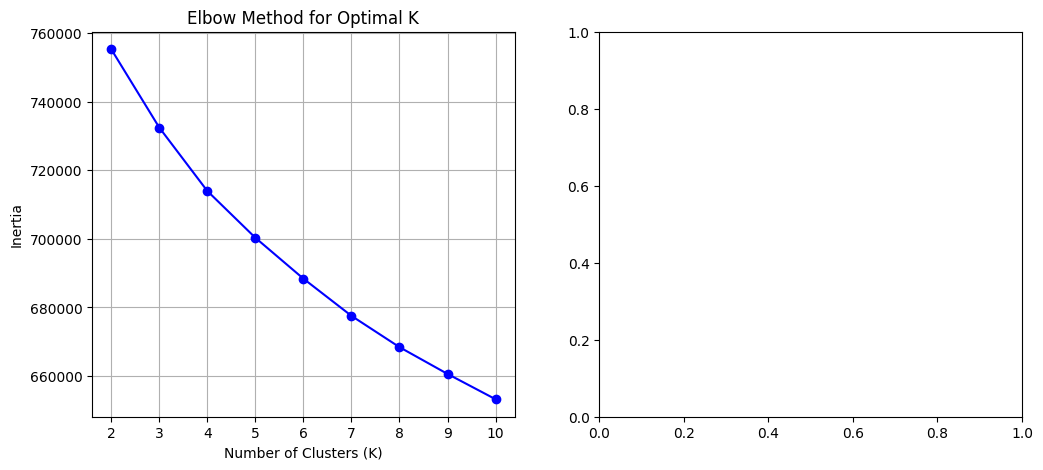

In [5]:
# Metode Elbow untuk menentukan jumlah cluster optimal
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_processed)
    inertia.append(kmeans.inertia_)
    if k > 1:  # Silhouette score hanya bisa dihitung untuk k > 1
        silhouette_scores.append(silhouette_score(X_processed, kmeans.labels_))

# Plot Elbow Method
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.grid(True)

# Plot Silhouette Scores
plt.subplot(1, 2, 2)
plt.plot(list(K_range)[1:], silhouette_scores, 'ro-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal K')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Tentukan jumlah cluster optimal berdasarkan elbow point
kl = KneeLocator(K_range, inertia, curve='convex', direction='decreasing')
optimal_k = kl.elbow
if optimal_k is None:
    # Jika KneeLocator tidak bisa mendeteksi elbow point, ambil K dengan silhouette score tertinggi
    optimal_k = list(K_range)[1:][np.argmax(silhouette_scores)]

print(f"\nOptimal number of clusters (K): {optimal_k}")

# Terapkan KMeans dengan jumlah cluster optimal
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_processed)

# Reduksi dimensi dengan PCA untuk visualisasi
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_processed)

# Plot hasil clustering KMeans
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
for i in range(optimal_k):
    plt.scatter(X_pca[kmeans_labels == i, 0], X_pca[kmeans_labels == i, 1], label=f'Cluster {i+1}')
plt.title(f'KMeans Clustering with {optimal_k} Clusters')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()

In [ ]:
# Tentukan parameter eps optimal menggunakan k-distance graph
nbrs = NearestNeighbors(n_neighbors=5).fit(X_processed)
distances, _ = nbrs.kneighbors(X_processed)
distances = np.sort(distances, axis=0)
distances = distances[:, 4]  # k=5, jadi ambil jarak ke tetangga ke-5

plt.figure(figsize=(10, 6))
plt.plot(np.arange(len(distances)), distances)
plt.title('K-distance Graph (k=5)')
plt.xlabel('Points sorted by distance')
plt.ylabel('5-NN Distance')
plt.grid(True)
plt.show()

# Tentukan eps berdasarkan "elbow" pada k-distance graph
# Untuk tujuan demonstrasi, kita akan menggunakan nilai eps yang reasonable
eps = np.percentile(distances, 90)  # 90th percentile as a heuristic
min_samples = 5

print(f"\nDBSCAN parameters: eps={eps:.4f}, min_samples={min_samples}")

In [ ]:
# Terapkan DBSCAN
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
dbscan_labels = dbscan.fit_predict(X_processed)

# Hitung jumlah cluster dan noise points
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)
print(f"Number of clusters: {n_clusters}")
print(f"Number of noise points: {n_noise} ({n_noise/len(dbscan_labels)*100:.2f}%)")

# Plot hasil clustering DBSCAN
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
# Plot noise points
plt.scatter(X_pca[dbscan_labels == -1, 0], X_pca[dbscan_labels == -1, 1], color='black', marker='x', label='Noise')
# Plot cluster points
unique_labels = set(dbscan_labels)
unique_labels.discard(-1)  # Hapus noise label (-1)
for label in unique_labels:
    plt.scatter(X_pca[dbscan_labels == label, 0], X_pca[dbscan_labels == label, 1], label=f'Cluster {label+1}')
plt.title(f'DBSCAN Clustering with {n_clusters} Clusters')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()

In [ ]:
# Bandingkan hasil KMeans dan DBSCAN
plt.figure(figsize=(15, 6))

# KMeans
plt.subplot(1, 2, 1)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', s=30, alpha=0.8)
plt.title(f'KMeans Clustering ({optimal_k} clusters)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(scatter)

# DBSCAN
plt.subplot(1, 2, 2)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='viridis', s=30, alpha=0.8)
plt.title(f'DBSCAN Clustering ({n_clusters} clusters, {n_noise} noise points)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(scatter)

plt.tight_layout()
plt.show()

In [ ]:
 Analisis perbandingan cluster
print("\nPerbandingan KMeans dan DBSCAN:")
print(f"1. KMeans membentuk {optimal_k} cluster dengan bentuk bola yang seimbang")
print(f"2. DBSCAN membentuk {n_clusters} cluster dengan bentuk yang tidak teratur dan mengidentifikasi {n_noise} titik noise")

# Analisis karakteristik cluster KMeans
df['KMeans_Cluster'] = kmeans_labels
print("\nAnalisis cluster KMeans:")
for i in range(optimal_k):
    cluster_data = df[df['KMeans_Cluster'] == i]
    print(f"\nCluster {i+1} ({len(cluster_data)} pasien):")
    for col in ['Age', 'BMI', 'Blood_Pressure', 'Cholesterol', 'Heart_Rate']:
        print(f"- Rata-rata {col}: {cluster_data[col].mean():.2f}")
    
    # Hitung proporsi pada kolom kategorikal
    for col in ['Smoking', 'Diabetes', 'Heart_Disease_History', 'Obesity']:
        if col in df.columns:
            print(f"- Proporsi {col}: {sum(cluster_data[col])/len(cluster_data)*100:.2f}%")


In [ ]:
# Visualisasi distribusi fitur penting berdasarkan cluster
plt.figure(figsize=(15, 10))

# BMI distribution
plt.subplot(2, 2, 1)
sns.boxplot(x='KMeans_Cluster', y='BMI', data=df)
plt.title('BMI Distribution by Cluster')

# Age distribution
plt.subplot(2, 2, 2)
sns.boxplot(x='KMeans_Cluster', y='Age', data=df)
plt.title('Age Distribution by Cluster')

# Blood Pressure distribution
plt.subplot(2, 2, 3)
sns.boxplot(x='KMeans_Cluster', y='Blood_Pressure', data=df)
plt.title('Blood Pressure Distribution by Cluster')

# Heart Rate distribution
plt.subplot(2, 2, 4)
sns.boxplot(x='KMeans_Cluster', y='Heart_Rate', data=df)
plt.title('Heart Rate Distribution by Cluster')

plt.tight_layout()
plt.show()